### Question 5: Implementation Gap

**Compare yield-space P&L to bond-space returns.**

This question confronts the gap between academic factor analysis and implementable trades.

a) **Design a roll schedule.** Using the bond panel (`treasury_panel_pca.xlsx`), you need to select actual bonds to proxy 2Y, 5Y, and 10Y maturities. Decide on:
   - **Roll frequency:** monthly or quarterly?
   - **Selection criteria:** closest TTM to target? Prefer on-the-run (low `age_days`)?
   
   Document your choices and rationale. There is no single correct answer—tradeoffs exist between tracking error, transaction costs, and liquidity.

b) **Construct the butterfly using actual bonds.** At each roll date:
   - Select the bond closest to each target maturity (2Y, 5Y, 10Y)
   - Apply your PCA-neutral weights, scaled by duration
   - Hold these bonds until the next roll date
   
   Compute daily bond returns between roll dates (price changes plus accrued interest changes).

c) **Compare yield-space vs bond-space P&L.** Compute the correlation and R² between:
   - Yield-space butterfly changes (from Question 3)
   - Bond-space portfolio returns
   
   Plot both series on the same chart.

d) **Analyze the sources of discrepancy:**

   - **Yield changes**: At each timestep, the indivudal bond's yield change will be different than the fixed maturity yield change. This is due to different maturities as well as factors idiosyncratic to the bond itself. How correlated are GSW yield changes with held bond yield changes? Show the relationship with a plot.
     
   - **First-order approxiation**: We can model bond returns from yields via first order approximation via duration. How correlated are our approximated returns to the actual bond returns? Show the relationship with a plot.

e) **Discuss:** Is the yield-space backtest a reliable guide to actual trading performance? What adjustments would you make for a production implementation?

## Data Loading

    Initial data loading, exploration, and notebook scaffolding for this question were developed with the assistance of Claude Code (Opus 4.6, Anthropic)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
gsw = pd.read_excel("data/gsw_yields.xlsx", index_col=0, parse_dates=True)
maturities = [2, 5, 10]
yields = gsw[maturities].dropna()
yields.columns = ["2Y", "5Y", "10Y"]
yields = yields.loc["2015":]
yields_diff = yields.diff(periods=1).dropna()

weights = np.ndarray([])
%store -r weights
print(f"Butterfly weights: {weights}")

panel = pd.read_excel(
    "data/treasury_panel_pca.xlsx", parse_dates=["caldt", "issue_date", "maturity_date"]
)
print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel['caldt'].min().date()} to {panel['caldt'].max().date()}")
print(f"Unique dates: {panel['caldt'].nunique()}, Unique bonds: {panel['kytreasno'].nunique()}")

In [3]:
panel.head(10)

,caldt,kytreasno,cusip,type,issue_date,maturity_date,ttm,age_days,coupon,ytm,price,accrued_int,dirty_price,duration
0,2022-01-03,207470,912828Z2,note,2020-01-15,2023-01-15,1.032170,719,1.500,0.004412,101.089844,0.701087,101.790931,1.021804
1,2022-01-03,206940,912828P3,note,2016-01-31,2023-01-31,1.075975,2164,1.750,0.004530,101.390625,0.741848,102.132473,1.063840
2,2022-01-03,207174,9128283U,note,2018-01-31,2023-01-31,1.075975,1433,2.375,0.004478,102.066406,1.006793,103.073200,1.059402
3,2022-01-03,207663,91282CBG,note,2021-01-31,2023-01-31,1.075975,337,0.125,0.004456,99.656250,0.052989,99.709239,1.075771
4,2022-01-03,204081,912810EP,bond,1993-02-15,2023-02-15,1.117043,10549,7.125,0.004844,107.386719,2.729959,110.116678,1.069214
5,2022-01-03,206591,912828UN,note,2013-02-15,2023-02-15,1.117043,3244,2.000,0.004690,101.703125,0.766304,102.469429,1.103149
6,2022-01-03,207489,912828Z8,note,2020-02-15,2023-02-15,1.117043,688,1.375,0.004585,101.019531,0.526834,101.546365,1.107638
7,2022-01-03,206948,912828P7,note,2016-02-29,2023-02-28,1.152635,2135,1.500,0.004683,101.187500,0.517956,101.705456,1.142410
8,2022-01-03,207184,9128284A,note,2018-02-28,2023-02-28,1.152635,1405,2.625,0.004858,102.460938,0.906423,103.367360,1.134460
9,2022-01-03,207674,91282CBN,note,2021-02-28,2023-02-28,1.152635,309,0.125,0.004791,99.593750,0.043163,99.636913,1.152488


In [4]:
panel.describe()

,caldt,kytreasno,issue_date,maturity_date,ttm,age_days,coupon,ytm,price,accrued_int,dirty_price,duration
count,204868,204868.000000,204868,204868,204868.000000,204868.000000,204868.000000,204868.000000,204868.000000,204868.000000,204868.000000,204868.000000
mean,2023-12-29 22:13:16.376203,207468.793125,2019-10-10 02:43:39.677060,2027-09-11 03:17:50.995958,3.699416,1541.812230,2.675650,0.038907,96.504589,0.655434,97.160023,3.456354
min,2022-01-03 00:00:00,204081.000000,1993-02-15 00:00:00,2023-01-15 00:00:00,1.002053,-9.000000,0.125000,0.004195,75.003906,0.000000,75.114300,0.952123
25%,2023-01-03 00:00:00,207361.000000,2019-05-15 00:00:00,2025-12-15 00:00:00,1.963039,359.000000,1.250000,0.036072,93.101562,0.178867,93.463083,1.919709
50%,2023-12-28 00:00:00,207730.000000,2021-06-15 00:00:00,2027-05-31 00:00:00,3.230664,871.000000,2.625000,0.040265,96.890625,0.480978,97.488731,3.114782
75%,2024-12-27 00:00:00,207989.000000,2022-12-31 00:00:00,2029-02-15 00:00:00,4.936345,1622.000000,4.000000,0.043832,99.972656,0.969613,100.800722,4.610975
max,2025-12-31 00:00:00,208504.000000,2025-12-31 00:00:00,2037-05-15 00:00:00,12.000000,10776.000000,7.625000,0.055252,136.929688,3.791780,137.775682,9.458658
std,NaN,997.015130,NaN,NaN,2.100097,2265.353203,1.633997,0.008153,5.932123,0.602986,6.262930,1.822890


In [5]:
target_mats = [2, 5, 10]
tolerance = 0.5

sample_date = panel["caldt"].iloc[len(panel) // 2]
day = panel[panel["caldt"] == sample_date]

print(f"Sample date: {sample_date.date()} ({len(day)} bonds)")
print()
for t in target_mats:
    nearby = day[(day["ttm"] >= t - tolerance) & (day["ttm"] <= t + tolerance)]
    print(f"""--- {t}Y bucket (TTM {t - tolerance:.1f} to {t + tolerance:.1f}) ---
    {len(nearby)} bonds, age_days range: {nearby["age_days"].min():.0f} to {
        nearby["age_days"].max():.0f}"
    TTM range: {nearby["ttm"].min():.2f} to {nearby["ttm"].max():.2f}")

        {
        nearby[["kytreasno", "cusip", "ttm", "age_days", "duration", "ytm", "type"]]
        .sort_values("ttm")
        .head()
        .to_string(index=False)
    }
    
    """)

Sample date: 2023-12-28 (207 bonds)

--- 2Y bucket (TTM 1.5 to 2.5) ---
    49 bonds, age_days range: -3 to 10362"
    TTM range: 1.51 to 2.46")

         kytreasno    cusip      ttm  age_days  duration      ytm type
    207224 912828XZ 1.505818      2007  1.465811 0.045006 note
    207560 912828ZW 1.505818      1276  1.502927 0.044973 note
    208073 91282CHL 1.505818       181  1.440285 0.044853 note
    207915 91282CEY 1.546886       531  1.503403 0.044823 note
    207232 912828Y7 1.590691      1976  1.549001 0.044602 note

    
--- 5Y bucket (TTM 4.5 to 5.5) ---
    26 bonds, age_days range: -3 to 9266"
    TTM range: 4.51 to 5.42")

         kytreasno    cusip      ttm  age_days  duration      ytm type
    207732 91282CCH 4.506502       911  4.360718 0.038853 note
    208075 91282CHK 4.506502       181  4.091957 0.038813 note
    207745 91282CCR 4.591376       880  4.473899 0.038804 note
    208087 91282CHQ 4.591376       150  4.166386 0.038685 note
    204092 912810FE 4.632444   

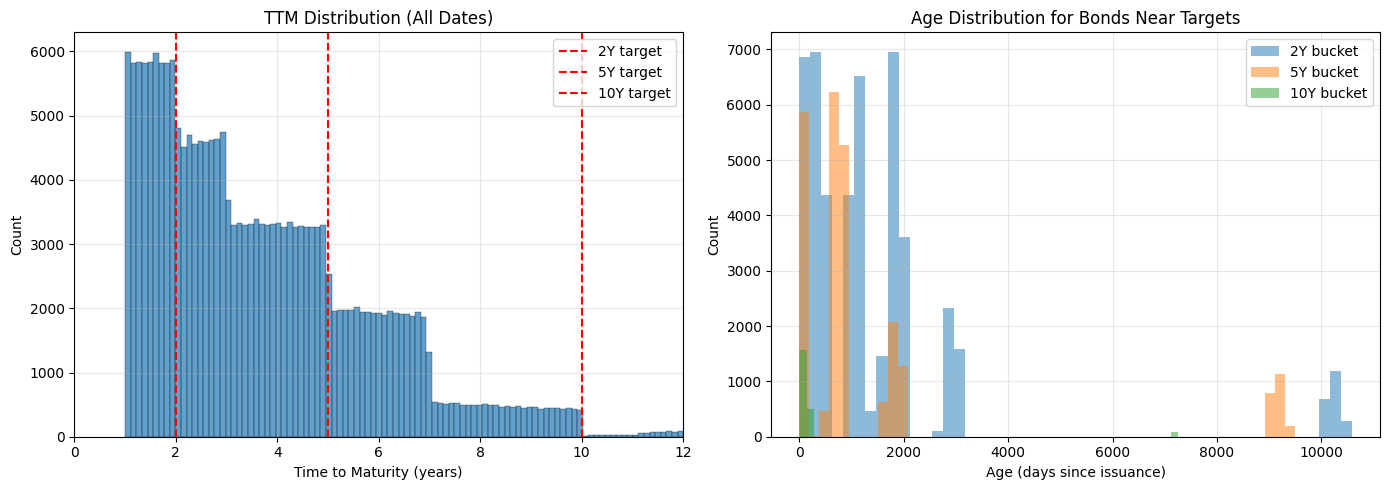

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(panel["ttm"], bins=100, alpha=0.7, edgecolor="black", linewidth=0.3)
for t in target_mats:
    axes[0].axvline(t, color="red", linestyle="--", linewidth=1.5, label=f"{t}Y target")
axes[0].set_title("TTM Distribution (All Dates)")
axes[0].set_xlabel("Time to Maturity (years)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].set_xlim(0, 12)
axes[0].grid(True, alpha=0.3)

for t in target_mats:
    nearby = panel[(panel["ttm"] >= t - tolerance) & (panel["ttm"] <= t + tolerance)]
    axes[1].hist(nearby["age_days"], bins=50, alpha=0.5, label=f"{t}Y bucket")
axes[1].set_title("Age Distribution for Bonds Near Targets")
axes[1].set_xlabel("Age (days since issuance)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
panel_dates = panel["caldt"].sort_values().unique()
gsw_dates = yields_diff.index

overlap_start = max(panel_dates.min(), gsw_dates.min())
overlap_end = min(panel_dates.max(), gsw_dates.max())
print(f"Overlap period: {pd.Timestamp(overlap_start).date()} to {pd.Timestamp(overlap_end).date()}")

yields_overlap = yields.loc[overlap_start:overlap_end]
yields_diff_overlap = yields_diff.loc[overlap_start:overlap_end]
panel_overlap = panel[(panel["caldt"] >= overlap_start) & (panel["caldt"] <= overlap_end)]
print(f"GSW trading days in overlap: {len(yields_diff_overlap)}")
print(f"Panel trading days in overlap: {panel_overlap['caldt'].nunique()}")

Overlap period: 2022-01-03 to 2025-12-26
GSW trading days in overlap: 995
Panel trading days in overlap: 996


In [8]:
# Mean-reversion strategy (from Question 3)
def mean_reversion(look_back_window, entry_threshold, exit_threshold, spread_data):
    rolling_mean = spread_data.rolling(window=look_back_window).mean()
    rolling_std = spread_data.rolling(window=look_back_window).std()
    z_scores = (spread_data - rolling_mean) / rolling_std

    signals = pd.DataFrame(index=spread_data.index)
    signals["Position"] = 0
    signals["Z_Score"] = z_scores

    signals.loc[z_scores > entry_threshold, "Position"] = -1
    signals.loc[z_scores < -entry_threshold, "Position"] = 1
    signals.loc[abs(z_scores) < exit_threshold, "Position"] = 999

    signals["Position"] = signals["Position"].replace(0, np.nan).ffill().fillna(0)
    signals["Position"] = signals["Position"].replace(999, 0)

    return signals, z_scores


def backtest_strategy(signals, spread_data):
    daily_changes = spread_data.diff()
    strategy_returns = signals["Position"].shift(1) * daily_changes
    cumulative_returns = strategy_returns.cumsum()
    return strategy_returns, cumulative_returns


LOOK_BACK = 20
ENTRY_THRESHOLD = 1.5
EXIT_THRESHOLD = 0.5
YIELD_SCALE = 100

## Part (a): Roll Schedule Design

We roll quarterly (QS), selecting the bond closest to each target maturity (2Y, 5Y, 10Y) with age as tiebreaker (prefer fresher issues for liquidity). Quarterly balances the key tradeoffs:
- **Monthly** tracks target maturities tightly but incurs ~4x the transaction costs for marginal improvement
- **Semi-annual/annual** reduces turnover but lets TTM drift too much when compared to quarterly, introducing basis risk
- **Quarterly** keeps TTM within reasonable distance of target with only 4 rolls/year

**Bond selection**: `select_bond` sorts candidates first by absolute TTM distance from target, then by `age_days` ascending. Minimizing TTM distance is the primary objective, as a bond closer to the target maturity better proxies the constant-maturity GSW yield, reducing the yield mapping error analyzed in Part (d). The age tiebreaker selects the most recently issued bond among equidistant candidates: newer issues are closer to on-the-run status, meaning tighter bid-ask spreads and deeper order books. Some bonds appear in the panel with negative `age_days` (trading in when-issued form before their official settlement date). We include them since the panel provides valid prices, yields, and durations for these observations, and excluding them would discard the freshest available proxy at roll dates near new issuance.

The 10Y bucket shows the most tracking variability due to sparser issuance at that tenor. The TTM tracking plots below compare all four frequencies.

In [9]:
def select_bond(day_panel: pd.DataFrame, target_maturity: float) -> pd.Series:
    _panel = day_panel.assign(ttm_dist=(pd.col("ttm") - target_maturity).abs()).sort_values(
        ["ttm_dist", "age_days"]
    )

    return _panel.iloc[0]


def build_roll_schedule(panel: pd.DataFrame, target_maturities: list, freq: str) -> pd.DataFrame:
    dates = panel["caldt"].sort_values().unique()
    roll_dates = pd.date_range(dates.min(), dates.max(), freq=freq)
    roll_dates = [min(dates, key=lambda d: abs(d - rd)) for rd in roll_dates]
    roll_dates = sorted(set(roll_dates))

    records = []
    for rd in roll_dates:
        day = panel[panel["caldt"] == rd]
        record = {"roll_date": rd}
        for t in target_maturities:
            bond = select_bond(day, t)
            if bond is not None:
                record[f"{t}Y_id"] = bond["kytreasno"]
                record[f"{t}Y_ttm"] = bond["ttm"]
                record[f"{t}Y_duration"] = bond["duration"]
                record[f"{t}Y_age"] = bond["age_days"]
                record[f"{t}Y_cusip"] = bond["cusip"]
        records.append(record)

    return pd.DataFrame(records)

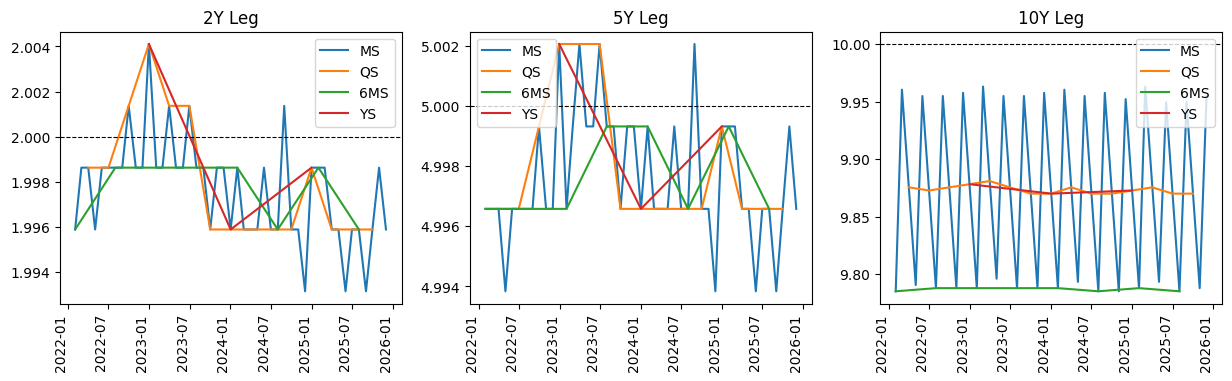

In [10]:
roll_schedules = ("MS", "QS", "6MS", "YS")
scheds = tuple(build_roll_schedule(panel, [2, 5, 10], freq=f) for f in roll_schedules)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, t in enumerate([2, 5, 10]):
    for roll, sched in zip(roll_schedules, scheds):
        axes[i].plot(sched["roll_date"], sched[f"{t}Y_ttm"], label=roll)

    axes[i].axhline(t, color="k", ls="--", lw=0.8)
    axes[i].set_title(f"{t}Y Leg")
    axes[i].legend()
fig.autofmt_xdate(rotation=90)

## Part (b): Bond-Space Butterfly Returns

The butterfly portfolio applies PCA-neutral weights scaled by duration (h = w/D) to actual bond dirty-price returns. Individual legs display duration-scaled volatility: the 10Y leg dominates, the 2Y is comparatively stable. The weighted portfolio return is an order of magnitude smaller than any single leg, as the PCA weighting removes most level and slope exposure.

In [11]:
ROLL_FREQ = "QS"
sched = build_roll_schedule(panel_overlap, [2, 5, 10], freq=ROLL_FREQ)

In [12]:
def compute_bond_returns(
    panel: pd.DataFrame, sched: pd.DataFrame, weights: np.ndarray
) -> pd.DataFrame:
    all_periods = []

    for i in range(len(sched) - 1):
        row = sched.iloc[i]
        next_roll = sched.iloc[i + 1]["roll_date"]

        bond_ids = [int(row[f"{t}Y_id"]) for t in target_mats]
        durations = np.array([row[f"{t}Y_duration"] for t in target_mats])
        h = weights / durations

        mask = (
            (panel["caldt"] >= row["roll_date"])
            & (panel["caldt"] <= next_roll)
            & panel["kytreasno"].isin(bond_ids)
        )
        period = panel[mask]

        def pivot_field(field):
            piv = period.pivot(index="caldt", columns="kytreasno", values=field)[bond_ids]
            piv.columns = [f"{t}_{field}" for t in target_mats]
            return piv

        df = pd.concat([pivot_field(f) for f in ("dirty_price", "ytm", "duration")], axis=1)

        for t in target_mats:
            df[f"{t}_ret"] = df[f"{t}_dirty_price"].pct_change()
            df[f"{t}_dytm"] = df[f"{t}_ytm"].diff()

        df = df.iloc[1:]
        df["port_return"] = df[[f"{t}_ret" for t in target_mats]].values @ h

        all_periods.append(df)

    return pd.concat(all_periods)

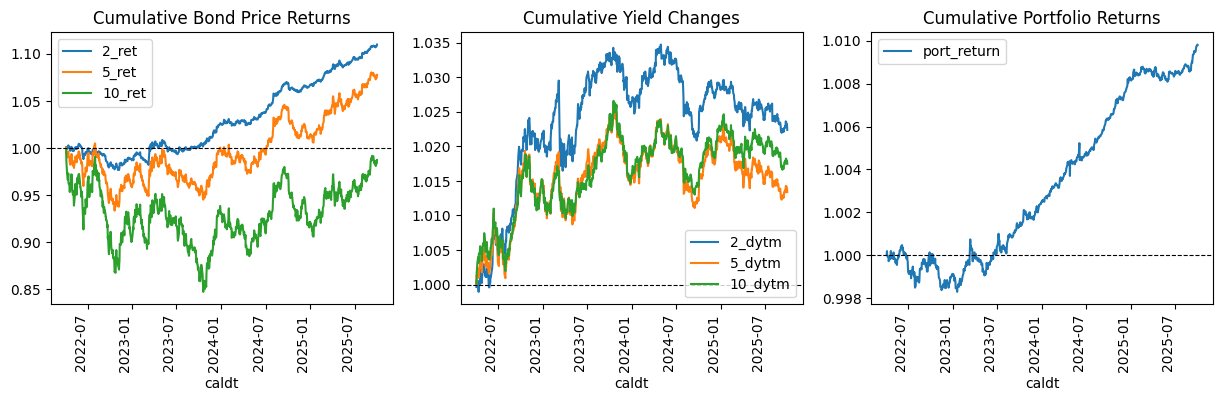

In [13]:
bond_returns = compute_bond_returns(panel_overlap, sched, weights)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bond_returns[[f"{t}_ret" for t in target_mats]].add(1).cumprod().plot(ax=axes[0])
bond_returns[[f"{t}_dytm" for t in target_mats]].cumsum().add(1).plot(ax=axes[1])
bond_returns[["port_return"]].add(1).cumprod().plot(ax=axes[2])


for i in range(3):
    axes[i].axhline(1.0, color="k", ls="--", lw=0.8)
    axes[i].legend()

axes[0].set_title("Cumulative Bond Price Returns")
axes[1].set_title("Cumulative Yield Changes")
axes[2].set_title("Cumulative Portfolio Returns")


fig.autofmt_xdate(rotation=90)

## Part (c): Yield-Space vs Bond-Space — Mean-Reversion Strategy

We apply the Question 3 mean-reversion strategy (lookback=20, entry=1.5 sigma, exit=0.5 sigma) to both spaces. The z-score signal is generated from the yield-space butterfly spread, then the same position is applied to yield-space spread changes and bond-space portfolio returns.

A sign subtlety: the Q3 position `pos=+1` means "long the yield spread" (expect curvature to rise). But the bond butterfly portfolio (h=w/D) is long wings, short body — it *loses* when curvature rises. So the bond-equivalent position is `-pos`: we short the butterfly when expecting curvature up, and vice versa.

Results: daily correlation is +0.48, but cumulative P&L diverges — yield-space shows Sharpe 0.67 while bond-space shows Sharpe -0.40. The strategy that appears profitable in yield space actually loses money in bonds. This is the opposite of the buy-and-hold comparison, where bond-space outperforms yield-space. The explanation is carry asymmetry (see Part e).

In [ ]:
yield_butterfly = yields_diff_overlap @ weights
yield_butterfly.name = "yield_butterfly"
all_returns = bond_returns.join(yield_butterfly).dropna()
all_returns["yield_scaled"] = -all_returns["yield_butterfly"] / YIELD_SCALE

yield_spread = yields_overlap @ weights
signals, z_scores = mean_reversion(LOOK_BACK, ENTRY_THRESHOLD, EXIT_THRESHOLD, yield_spread)

# Bond butterfly (h=w/D) is long wings, short body => loses when curvature rises
# So bond-equivalent position = -pos
common = bond_returns.index.intersection(signals.index)
pos = signals.loc[common, "Position"]

strat = pd.DataFrame(
    {
        "yield_strat": (pos.shift(1) * yield_spread.diff().loc[common]) / YIELD_SCALE,
        "bond_strat": -pos.shift(1) * bond_returns.loc[common, "port_return"],
        "position": pos,
        "z_score": z_scores.reindex(common),
    }
).dropna()

In [15]:
corr = strat["bond_strat"].corr(strat["yield_strat"])
r2 = corr**2

active = strat[strat["position"].shift(1) != 0]
corr_active = active["bond_strat"].corr(active["yield_strat"])
r2_active = corr_active**2

slope, intercept = np.polyfit(strat["yield_strat"], strat["bond_strat"], 1)

sharpe_yield = strat["yield_strat"].mean() / strat["yield_strat"].std() * np.sqrt(252)
sharpe_bond = strat["bond_strat"].mean() / strat["bond_strat"].std() * np.sqrt(252)

print(f"""Mean-reversion strategy comparison:
  Full sample:   corr={corr:.4f}, R²={r2:.4f} (N={len(strat)})
  Active days:   corr={corr_active:.4f}, R²={r2_active:.4f} (N={len(active)})
  OLS slope:     {slope:.4f}
  Yield-space:   cumul={strat["yield_strat"].sum():.6f}, Sharpe={sharpe_yield:.2f}
  Bond-space:    cumul={strat["bond_strat"].sum():.6f}, Sharpe={sharpe_bond:.2f}
  Active frac:   {(strat["position"] != 0).mean():.1%}""")

Mean-reversion strategy comparison:
  Full sample:   corr=0.4780, R²=0.2285 (N=873)
  Active days:   corr=0.4795, R²=0.2299 (N=465)
  OLS slope:     0.3304
  Yield-space:   cumul=0.004291, Sharpe=0.67
  Bond-space:    cumul=-0.001767, Sharpe=-0.40
  Active frac:   53.3%


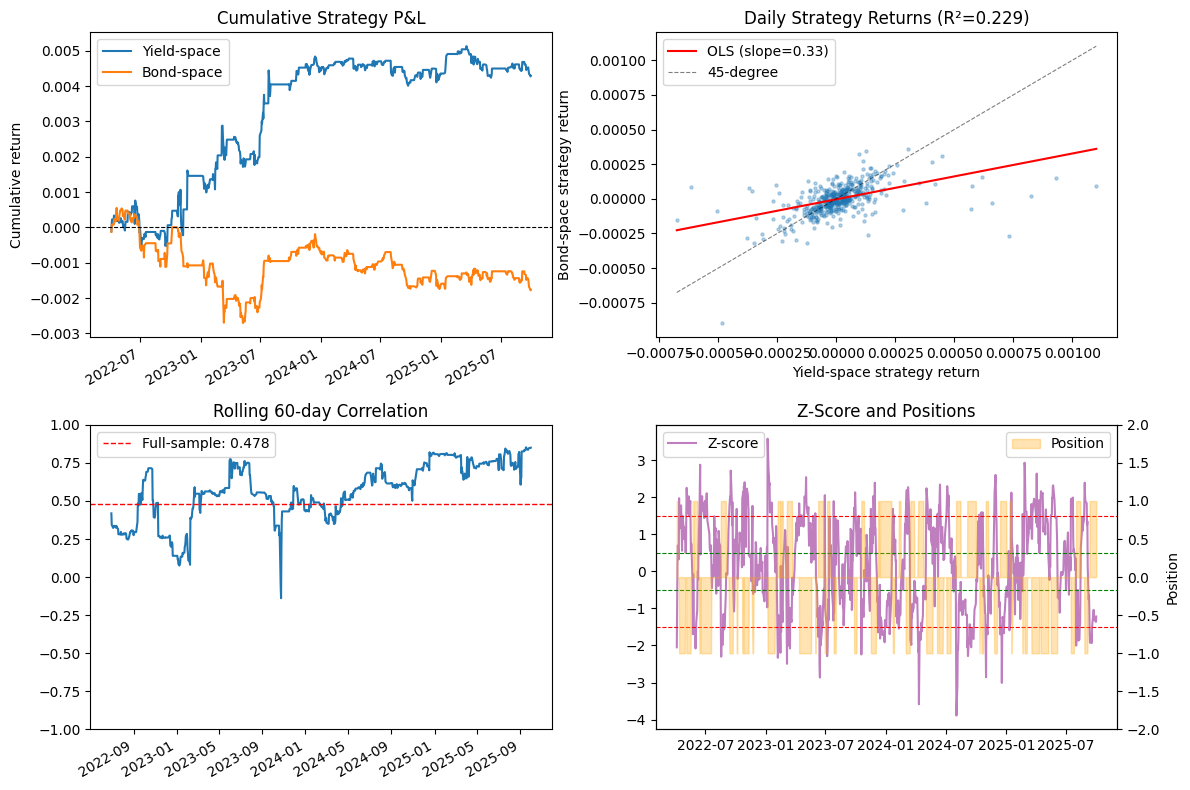

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Cumulative strategy P&L
strat["yield_strat"].cumsum().plot(ax=axes[0, 0], label="Yield-space")
strat["bond_strat"].cumsum().plot(ax=axes[0, 0], label="Bond-space")
axes[0, 0].set_title("Cumulative Strategy P&L")
axes[0, 0].axhline(0, color="k", ls="--", lw=0.8)
axes[0, 0].legend()
axes[0, 0].set_ylabel("Cumulative return")

# Scatter of daily strategy returns
axes[0, 1].scatter(strat["yield_strat"], strat["bond_strat"], alpha=0.3, s=5)
lims = [strat["yield_strat"].min(), strat["yield_strat"].max()]
axes[0, 1].plot(
    lims, np.polyval([slope, intercept], lims), "r-", lw=1.5, label=f"OLS (slope={slope:.2f})"
)
axes[0, 1].plot(lims, lims, "k--", lw=0.8, alpha=0.5, label="45-degree")
axes[0, 1].set_xlabel("Yield-space strategy return")
axes[0, 1].set_ylabel("Bond-space strategy return")
axes[0, 1].set_title(f"Daily Strategy Returns (R²={r2:.3f})")
axes[0, 1].legend()

# Rolling correlation
rolling_corr = strat["bond_strat"].rolling(60).corr(strat["yield_strat"])
rolling_corr.plot(ax=axes[1, 0])
axes[1, 0].axhline(corr, color="r", ls="--", lw=1, label=f"Full-sample: {corr:.3f}")
axes[1, 0].set_title("Rolling 60-day Correlation")
axes[1, 0].set_ylim(-1, 1)
axes[1, 0].legend()

# Z-score and position
axes[1, 1].plot(strat.index, strat["z_score"], alpha=0.5, label="Z-score", color="purple")
axes[1, 1].axhline(ENTRY_THRESHOLD, color="r", ls="--", lw=0.8)
axes[1, 1].axhline(-ENTRY_THRESHOLD, color="r", ls="--", lw=0.8)
axes[1, 1].axhline(EXIT_THRESHOLD, color="g", ls="--", lw=0.8)
axes[1, 1].axhline(-EXIT_THRESHOLD, color="g", ls="--", lw=0.8)
ax2 = axes[1, 1].twinx()
ax2.fill_between(strat.index, strat["position"], alpha=0.3, color="orange", label="Position")
ax2.set_ylabel("Position")
ax2.set_ylim(-2, 2)
axes[1, 1].set_title("Z-Score and Positions")
axes[1, 1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Part (d): Sources of Discrepancy

### d.i — Yield Mapping: GSW vs Held Bond Yield Changes

Three factors cause held-bond yield changes to differ from GSW constant-maturity yields:
- TTM mismatch: the bond ages between rolls while GSW interpolates at fixed maturity
- GSW is a fitted smooth curve while individual bonds price with idiosyncratic spreads
- On-the-run/off-the-run effects: per-leg correlations are high, but the butterfly weighting amplifies small residuals, degrading portfolio-level yield correspondence.

In [17]:
gsw_dy = yields_diff_overlap / YIELD_SCALE
gsw_dy.columns = [f"{t}_gsw_dy" for t in target_mats]

yield_compare = bond_returns[[f"{t}_dytm" for t in target_mats]].join(gsw_dy, how="inner")

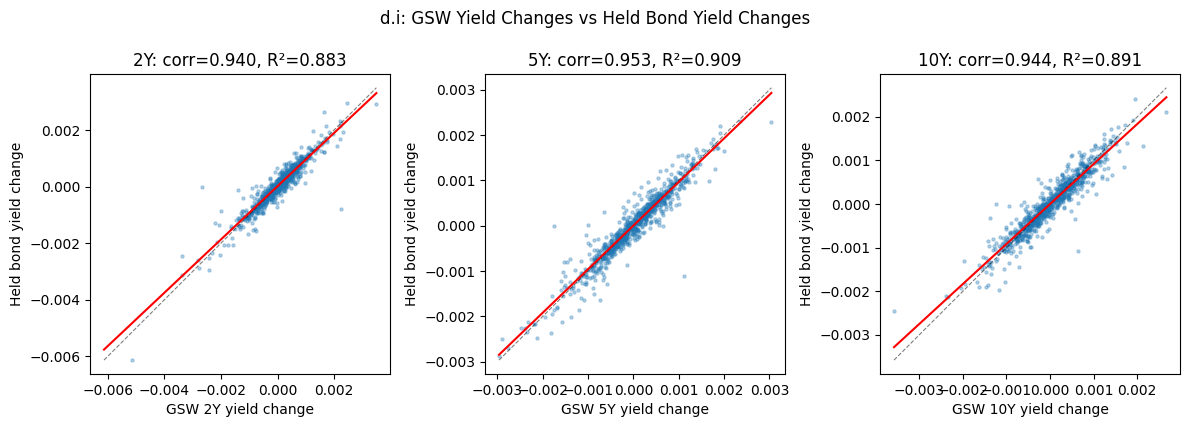

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = {2: "2Y", 5: "5Y", 10: "10Y"}

for i, t in enumerate(target_mats):
    x = yield_compare[f"{t}_gsw_dy"]
    y = yield_compare[f"{t}_dytm"]
    r = x.corr(y)

    axes[i].scatter(x, y, alpha=0.3, s=5)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    axes[i].plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    slope_i, int_i = np.polyfit(x, y, 1)
    axes[i].plot(lims, np.polyval([slope_i, int_i], lims), "r-", lw=1.5)
    axes[i].set_xlabel(f"GSW {labels[t]} yield change")
    axes[i].set_ylabel("Held bond yield change")
    axes[i].set_title(f"{labels[t]}: corr={r:.3f}, R²={r**2:.3f}")
    axes[i].set_aspect("equal")

plt.suptitle("d.i: GSW Yield Changes vs Held Bond Yield Changes", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
print("Per-leg yield mapping: GSW vs held bond yield changes")
for t in target_mats:
    x, y = yield_compare[f"{t}_gsw_dy"], yield_compare[f"{t}_dytm"]
    r = x.corr(y)
    print(f"  {labels[t]}: corr={r:.4f}, R²={r**2:.4f}")

bond_dy_w = yield_compare[[f"{t}_dytm" for t in target_mats]].values @ weights
gsw_dy_w = yield_compare[[f"{t}_gsw_dy" for t in target_mats]].values @ weights
r_port = np.corrcoef(bond_dy_w, gsw_dy_w)[0, 1]
print(f"\n  Portfolio (butterfly-weighted): corr={r_port:.4f}, R²={r_port**2:.4f}")

Per-leg yield mapping: GSW vs held bond yield changes
  2Y: corr=0.9397, R²=0.8831
  5Y: corr=0.9535, R²=0.9091
  10Y: corr=0.9439, R²=0.8910

  Portfolio (butterfly-weighted): corr=0.4249, R²=0.1806


### d.ii — Duration Approximation: First-Order vs Actual Returns

The duration approximation (ret = -D * dy) fits individual bond returns very well at daily frequency — convexity terms are negligible for typical daily yield moves of a few basis points. The systematic positive residual (actual minus approximated) reflects daily coupon accrual (carry) that the yield-based approximation ignores. While small per day, this carry residual accumulates over time and is the dominant driver of cumulative P&L drift.

In [20]:
dur_compare = pd.DataFrame(index=bond_returns.index)
for t in target_mats:
    dur_compare[f"{t}_ret"] = bond_returns[f"{t}_ret"]
    dur_compare[f"{t}_ret_approx"] = (
        -bond_returns[f"{t}_duration"].shift(1) * bond_returns[f"{t}_dytm"]
    )

dur_compare = dur_compare.dropna()

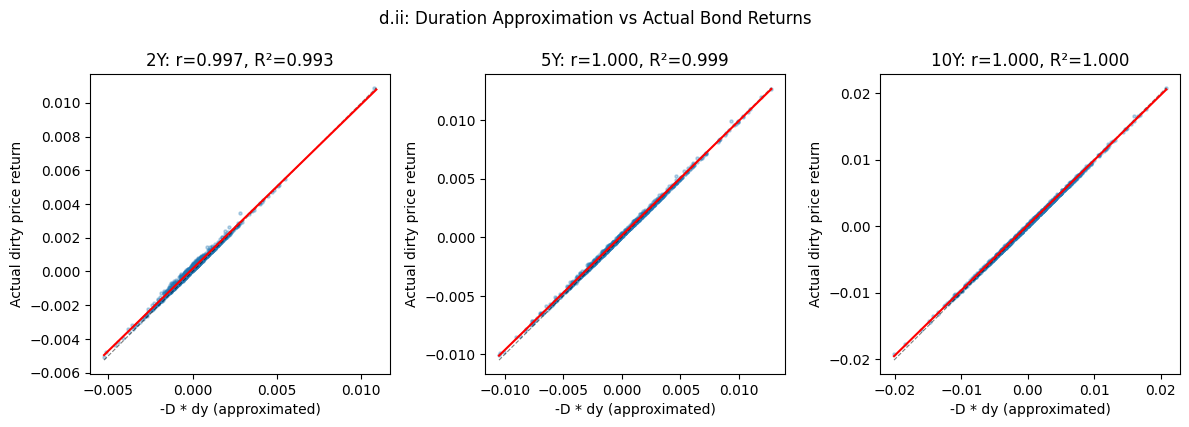

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, t in enumerate(target_mats):
    x = dur_compare[f"{t}_ret_approx"]
    y = dur_compare[f"{t}_ret"]
    r = x.corr(y)

    axes[i].scatter(x, y, alpha=0.3, s=5)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    axes[i].plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    slope_i, int_i = np.polyfit(x, y, 1)
    axes[i].plot(lims, np.polyval([slope_i, int_i], lims), "r-", lw=1.5)
    axes[i].set_xlabel("-D * dy (approximated)")
    axes[i].set_ylabel("Actual dirty price return")
    axes[i].set_title(f"{labels[t]}: r={r:.3f}, R²={r**2:.3f}")
    axes[i].set_aspect("equal")

plt.suptitle("d.ii: Duration Approximation vs Actual Bond Returns", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("Per-leg duration approximation fit:")
for t in target_mats:
    x, y = dur_compare[f"{t}_ret_approx"], dur_compare[f"{t}_ret"]
    r = x.corr(y)
    carry = (y - x).mean()
    print(f"  {labels[t]}: R²={r**2:.4f}, mean carry residual={carry * 1e4:.3f} bps/day")

bond_dytm = all_returns[[f"{t}_dytm" for t in target_mats]].values
gsw_dytm = gsw_dy.reindex(all_returns.index).values

decomp = pd.DataFrame(index=all_returns.index)
decomp["total_gap"] = all_returns["port_return"] - all_returns["yield_scaled"]
decomp["yield_mapping"] = -(bond_dytm - gsw_dytm) @ weights
decomp["carry_convexity"] = all_returns["port_return"] + bond_dytm @ weights
decomp = decomp.dropna()

print(f"\nBuy-and-hold gap decomposition ({len(decomp)} days):")
print(f"  Total gap:         {decomp['total_gap'].sum(): .6f}")
print(f"  Yield mapping:     {decomp['yield_mapping'].sum(): .6f}")
print(f"  Carry + convexity: {decomp['carry_convexity'].sum(): .6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
decomp[["total_gap", "yield_mapping", "carry_convexity"]].cumsum().plot(ax=axes[0])
axes[0].set_title("Cumulative Gap Decomposition")
axes[0].set_ylabel("Cumulative return")
axes[0].axhline(0, color="k", ls="--", lw=0.8)
axes[0].legend(fontsize=8)

all_returns["port_return"].cumsum().plot(ax=axes[1], label="Bond-space")
all_returns["yield_scaled"].cumsum().plot(ax=axes[1], label="Yield-space")
(
    all_returns["yield_scaled"] + decomp.reindex(all_returns.index)["carry_convexity"].fillna(0)
).cumsum().plot(ax=axes[1], label="Yield-space + carry", ls="--")
axes[1].set_title("Carry Correction Closes the Gap")
axes[1].axhline(0, color="k", ls="--", lw=0.8)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Part (e): Discussion

### Carry asymmetry: why the gap reverses under mean-reversion

The butterfly portfolio has positive net carry (+0.017 cumulative over 874 days, ~2 bps/day). Carry accrues from coupon payments on held bonds and is invisible in yield space. Its effect on the implementation gap depends entirely on position direction:

| | Buy-and-hold | Mean-reversion |
|---|---|---|
| Bond position | Always long butterfly | Alternates long/short |
| Carry effect | Always a tailwind | Tailwind when long, **headwind when short** |
| Bond vs yield | Bond >> yield (+0.014 gap) | Bond < yield (-0.006 gap) |

In buy-and-hold, the long butterfly earns carry every day, pushing bond-space P&L above yield-space. Under mean-reversion, the strategy shorts the butterfly roughly half the time (when `pos=+1` in Q3's yield-space convention). During these short periods, carry works *against* the bond position. If the strategy's net carry exposure is negative — more time or larger positions in the short direction — carry flips from tailwind to headwind, and bond-space underperforms yield-space.

This is the central finding: **carry doesn't care about your view**. It is a structural property of the bond portfolio. Buy-and-hold earns it; a strategy that alternates direction may pay it.

### Three layers of the implementation gap

1. **Carry** (dominant, ~2 bps/day per leg): drives cumulative divergence in both BnH and mean-reversion, but with opposite sign. Under BnH carry adds ~+0.017 to bond returns over the sample. Under mean-reversion, position-weighted carry is net negative.

2. **Yield mapping** (moderate, portfolio R²=0.18): per-leg GSW-to-bond correlations are ~0.94, but the butterfly weighting amplifies residual noise, degrading portfolio-level correspondence. This is a zero-mean noise source — it doesn't trend, but it adds variance.

3. **Duration approximation** (negligible, R²>0.99 per leg): convexity terms are irrelevant at daily frequency.

### Is the yield-space backtest reliable?

For **daily signal validation**, moderately: the 0.48 correlation confirms that yield-space signals contain real information about bond-space direction. For **cumulative P&L prediction**, no: the yield backtest shows a Sharpe of 0.67 while bonds show -0.40. A strategy that is profitable in yield space can lose money in bond space because carry overwhelms the modest mean-reversion alpha.

### Production adjustments

- Model carry explicitly: compute daily coupon accrual per position and subtract it from gross P&L
- Account for the position-carry interaction: a strategy that is frequently short the butterfly faces a structural carry headwind
- Track actual CUSIPs with financing (repo) costs — repo rates further modify the net carry of each leg
- Transaction costs: bid-ask at each roll + each strategy entry/exit, not just rolls
- Slippage: signals observed end-of-day, executed next open